# Evaluating a trained KIND model on ETTh2 dataset

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import python libraries and kind framework --!

import torch
import numpy as np

from matplotlib import pyplot as plt

import utils_data
import utils_plot

### Load a trained KIND model

In [2]:
# --! load a trained KIND model --!

model = torch.load('../../models/baselines/et_kind.pt', weights_only=False)
model.eval()

model(
  (operator_stat): operator_stationary(
    (fun_enc): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=12, out_features=128, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=128, out_features=128, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=128, out_features=192, bias=True)
          (1): Identity()
        )
      )
    )
    (mod_mean): Linear(in_features=8, out_features=8, bias=False)
    (mod_var_gen): fcnn(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (1): Sequential(
          (0): Linear(in_features=64, out_features=64, bias=True)
          (1): ReLU()
        )
        (2): Sequential(
          (0): Linear(in_features=64, out_features=768, bias=True)
          (1): Identity()
        )
      )
    )
    (pre_me

### Analyze the stationary part of a KIND model

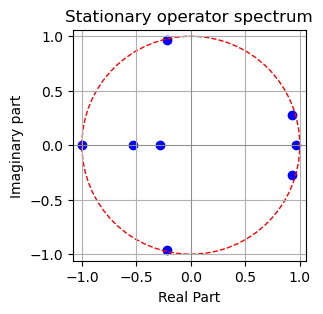

tensor([-0.2220+0.9637j, -0.2220-0.9637j, -0.9950+0.0000j, -0.5294+0.0000j,
        -0.2831+0.0000j,  0.9301+0.2745j,  0.9301-0.2745j,  0.9664+0.0000j])


In [3]:
# --! visualize stationary operator eigenvalues --!

with torch.no_grad():
    utils_plot.plot_eigs(model)

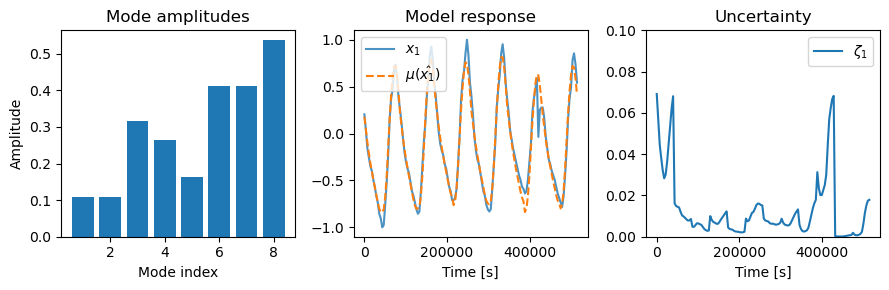

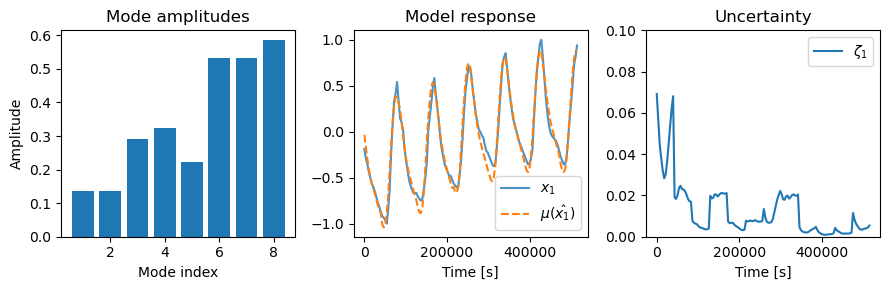

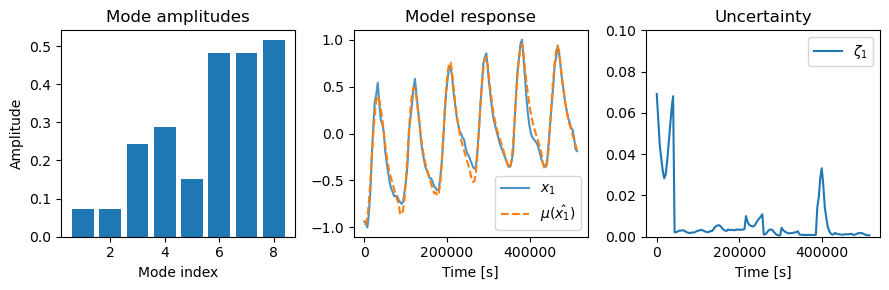

In [4]:
# --! analyze the contribution of stationary operator eigenvalues --!

datadir            = '../../data/baselines/et_train_stat'
timeseries_nsample = 144

with torch.no_grad():
    for jtimeseries in range(3):
        utils_plot.plot_modes(model, datadir, timeseries_nsample, jtimeseries)

### Evaluate KIND performance on test data

In [11]:
# --! make forecasts in a manner of a sliding window --!

datadir            = '../../data/baselines/et_test'
timeseries_nsample = 5996

mse_stat, mse_trans, mse_blend = utils_plot.plot_mse(model, datadir, timeseries_nsample)

test shape: (5852, 48, 1) (5852, 48, 1)
test shape: (5852, 48, 1) (5852, 48, 1)
Blend MSE : 18.723
Blend MAE : 3.162
Stat MSE : 44.343
Stat MAE : 5.015
Trans MSE : 18.981
Trans MAE : 3.171
Stat uncertainty : 0.37991222739219666
Trans uncertainty : 0.03199737146496773

inf >> forecasting results:

         mse      index      value
 -----------   --------   --------
  best blend       2546      0.005
 worst blend       1704      1.199
   avg blend         na      0.166
                                  
   best stat       3696      0.006
  worst stat       3170      1.614
    avg stat         na      0.377
                                  
  best trans       3327      0.004
 worst trans       1704      1.263
   avg trans         na      0.170

inf >> mean alpha is 0.14



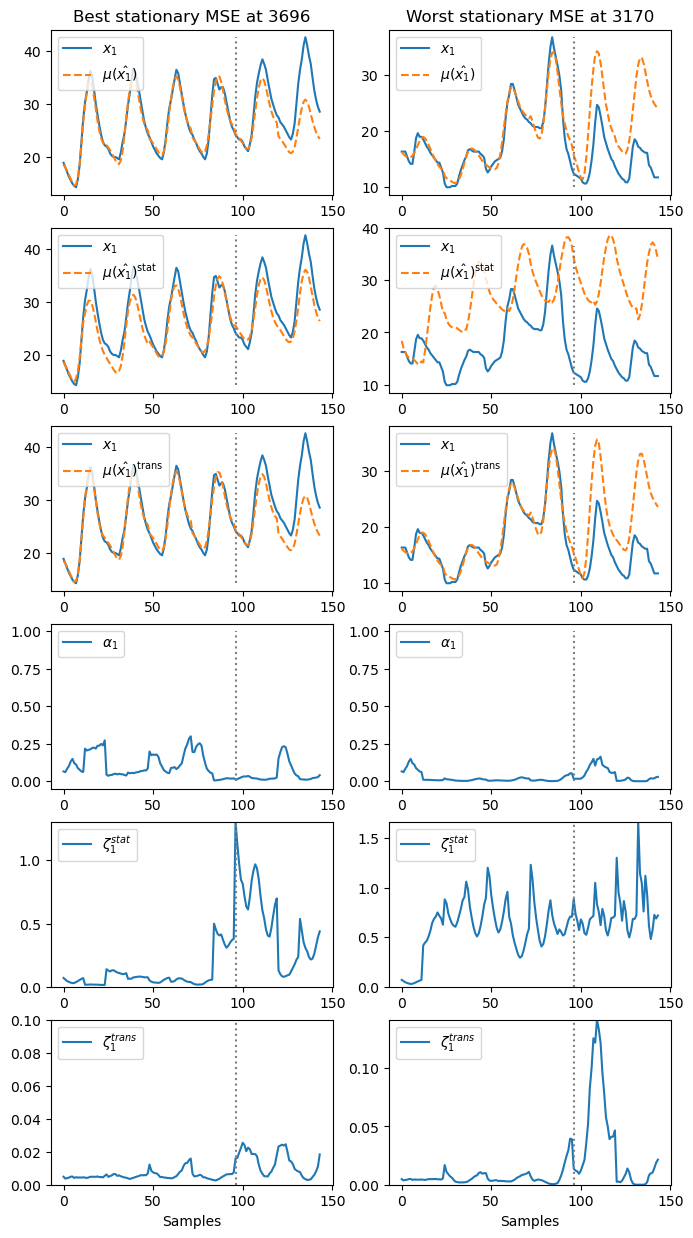

In [6]:
# --! plot the best and worst stationary performance --!

utils_plot.plot_mse_extreme(
    model,
    datadir,
    timeseries_nsample,
    mse_stat, mse_type='stationary',
    datasaved=True, savedir='../../savedata/baselines/et')

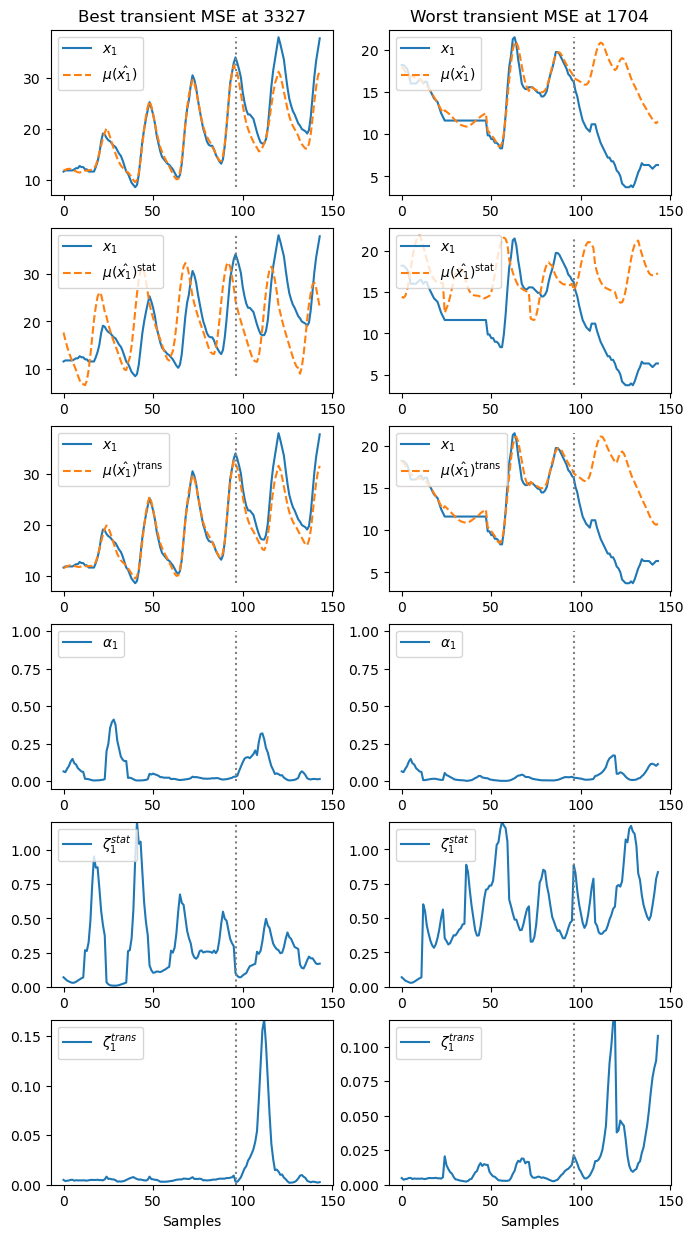

In [7]:
# --! plot the best and worst transient performance --!

utils_plot.plot_mse_extreme(
    model,
    datadir,
    timeseries_nsample,
    mse_trans, mse_type='transient',
    datasaved=True, savedir='../../savedata/baselines/et')

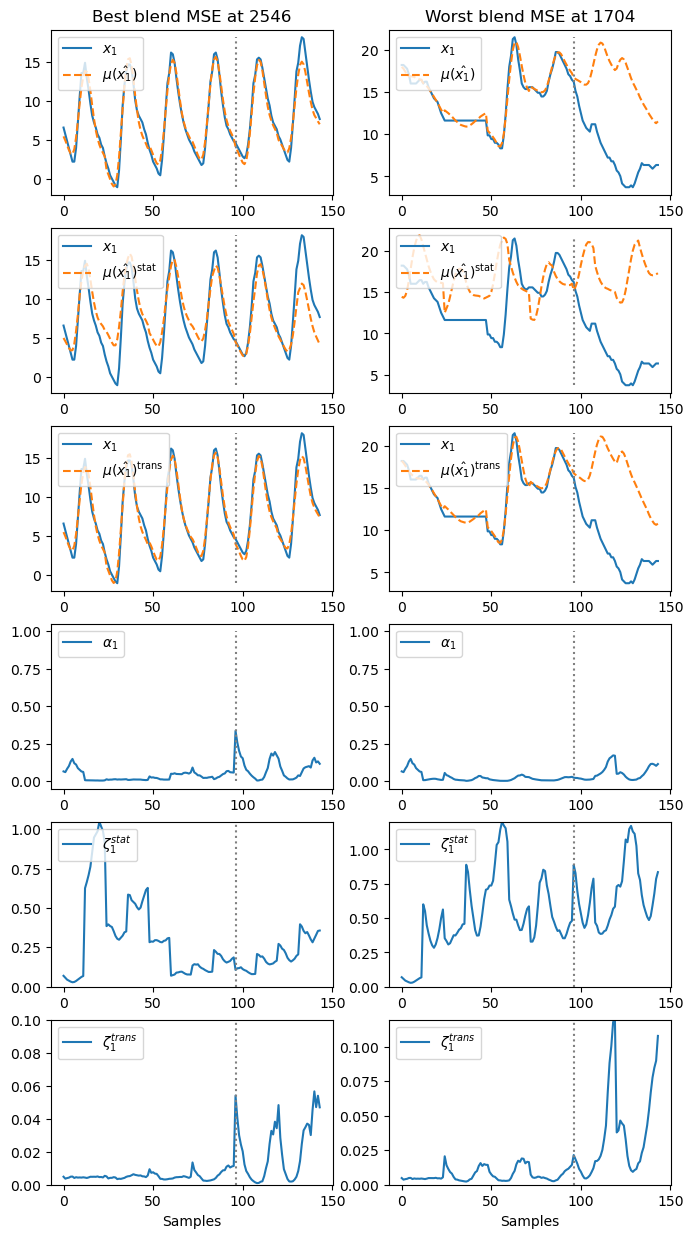

In [8]:
# --! plot the best and worst blending performance --!

utils_plot.plot_mse_extreme(
    model,
    datadir,
    timeseries_nsample,
    mse_blend, mse_type='blend',
    datasaved=True, savedir='../../savedata/baselines/et')

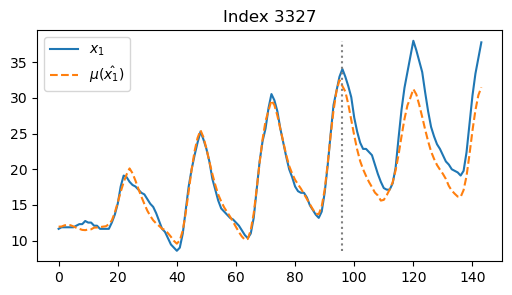

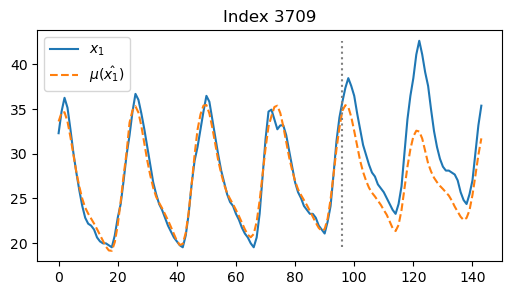

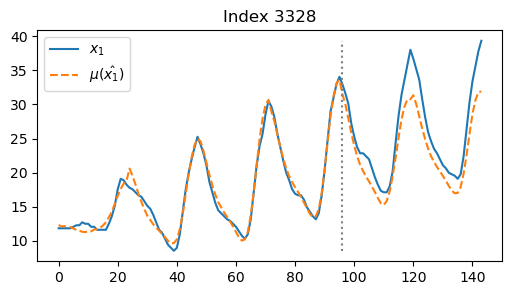

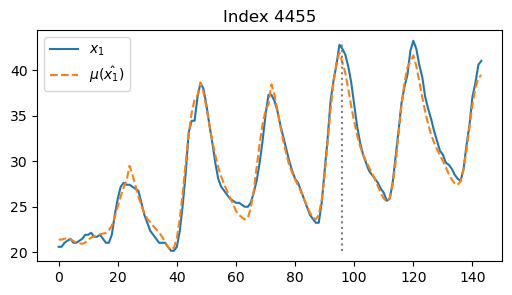

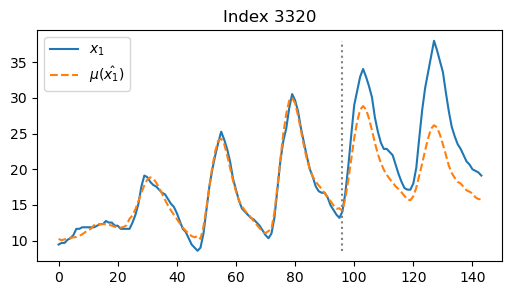

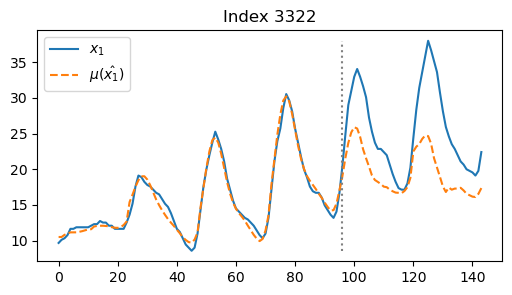

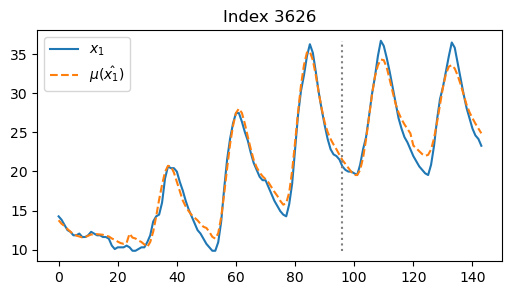

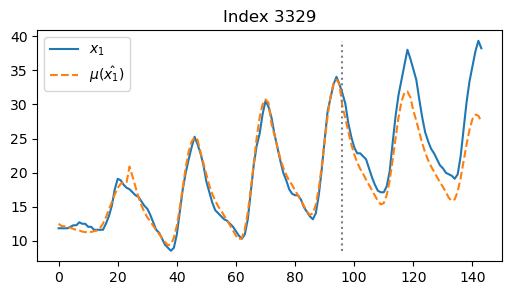

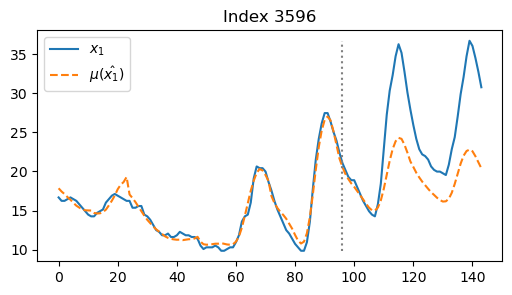

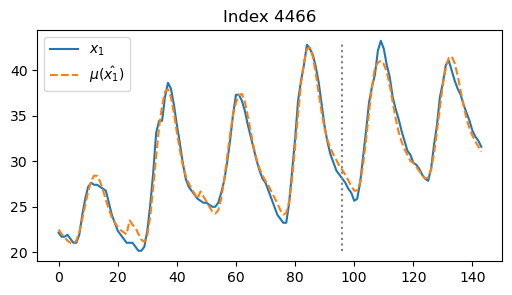

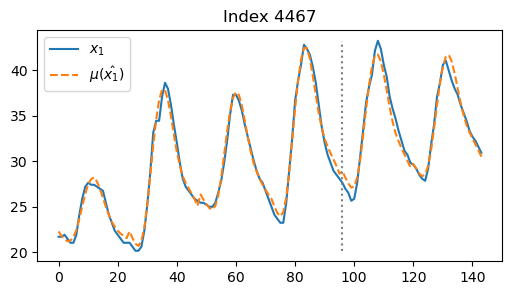

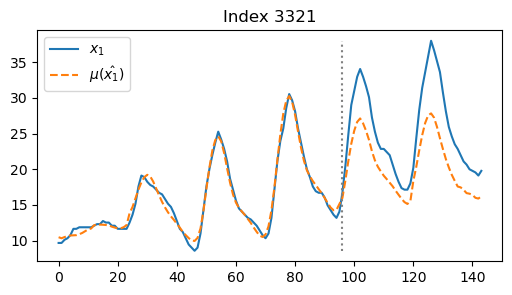

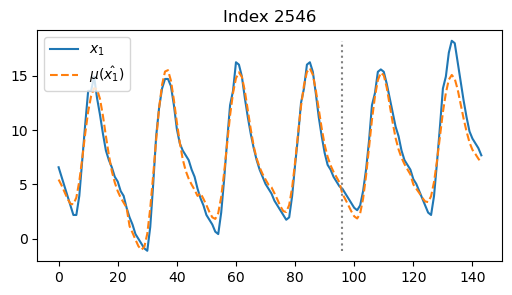

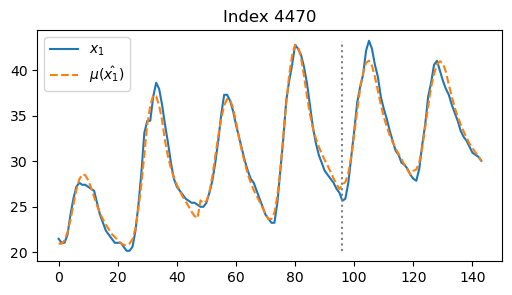

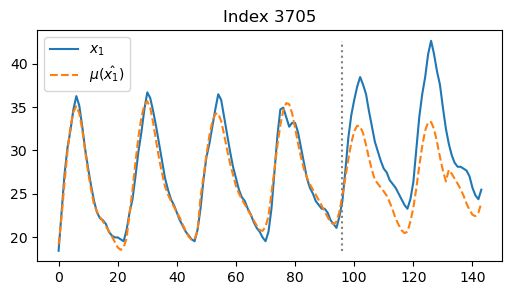

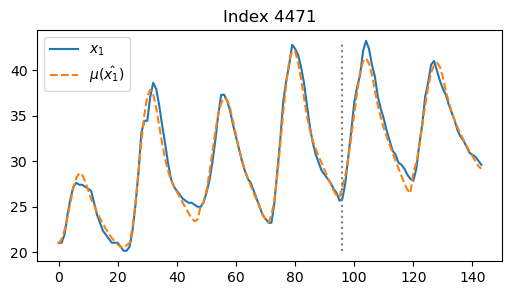

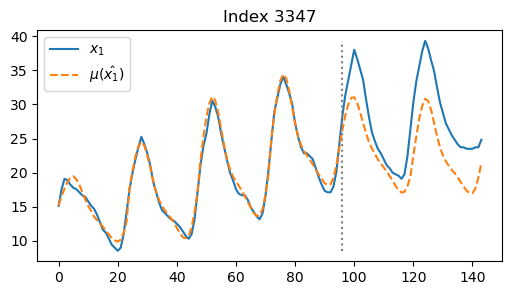

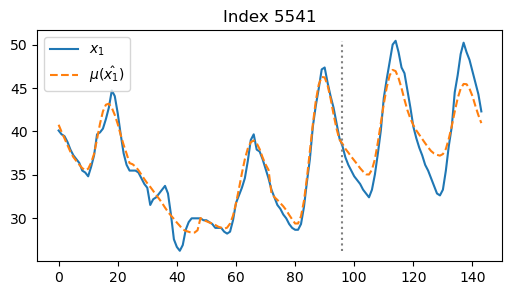

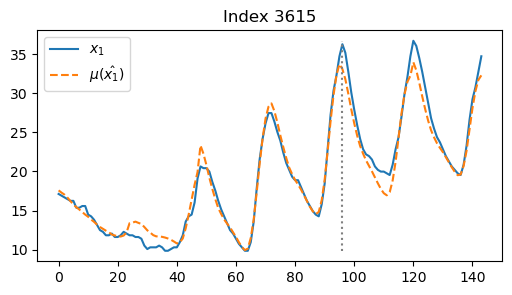

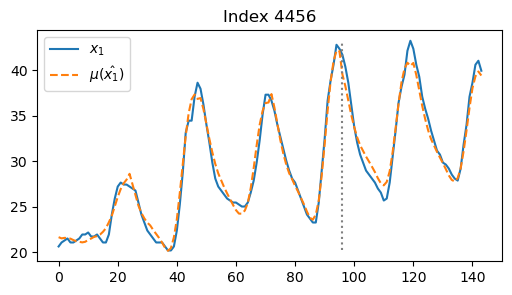

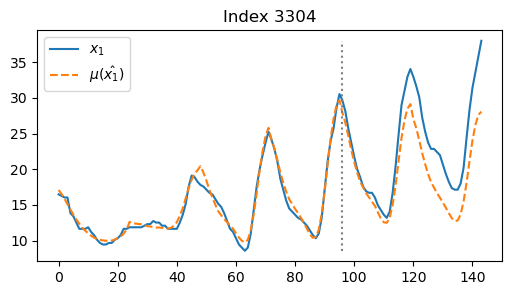

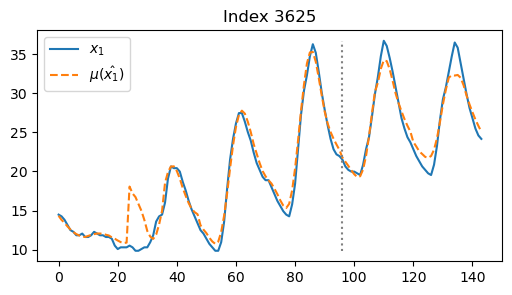

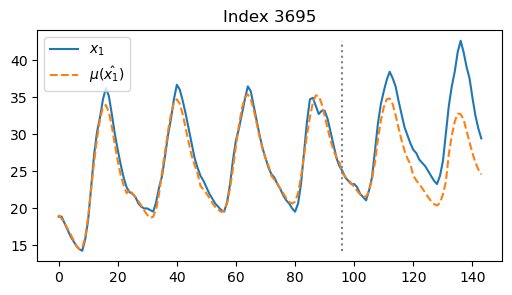

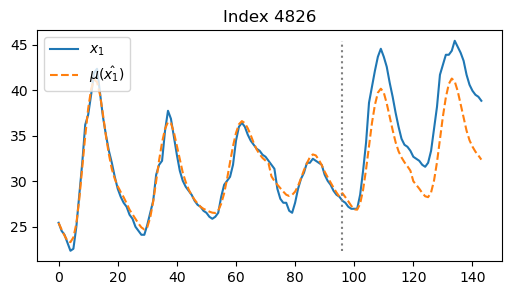

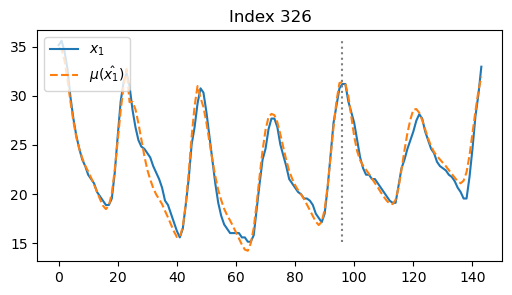

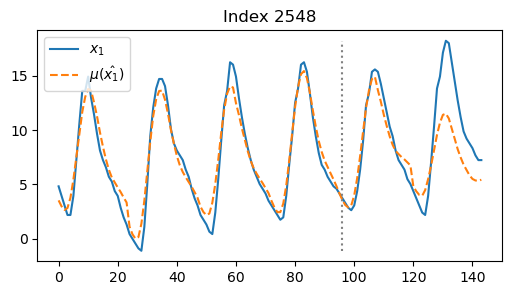

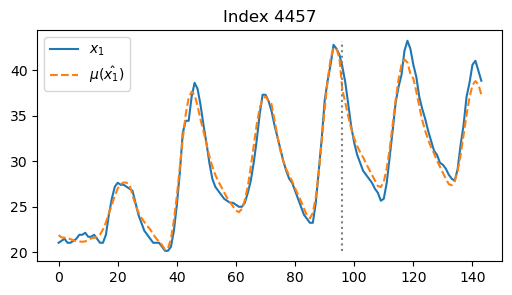

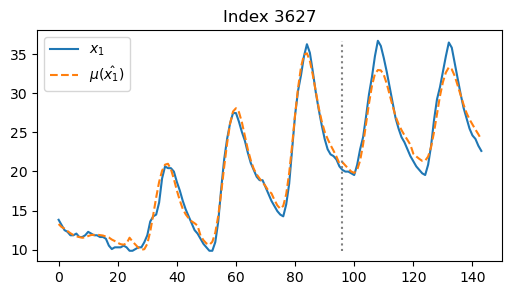

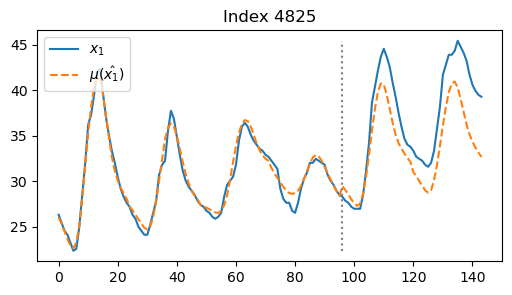

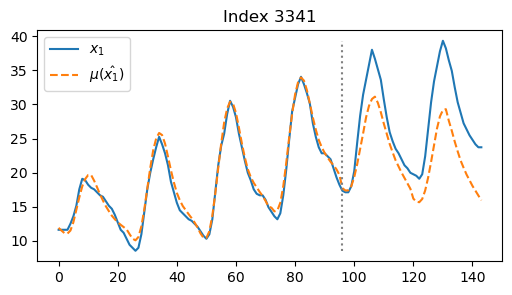

In [9]:
utils_plot.plot_mse_extreme2(
    model,
    datadir,
    timeseries_nsample,
    mse_blend, mse_type='blend',
    k=30,
    jsave=6093,
    datasaved=True, savedir='../../savedata/baselines/et')